### Introduction to Geospatial Analysis

If you have ever used Uber to see how close your driver is, used Google Maps to get somewhere, or checked the exact temperature of your location, you are already a beneficiary of Geospatial Analysis! Today, a considerable amount of data generated has a spatial component to it. Outside the rather complex use case of geospatial analysis in a ride sharing app like Uber, geospatial data especially when combined with traditional datasets-such as sales data, can unlock even deeper insights. For example, sales data combined with the store locations can reveal regional purchasing trends or health records combined with hospital locations can reveal gaps in healthcare coverage. In short, geospatial analysis, helps us uncover where things happen and why they happen there , making it a key skill to have as a Data Analyst.

A considerable proportion of the data generated every day is inherently spatial.

From Earth Observation data and GPS data to data included in all kinds of maps, `spatial data`, also known sometimes as `geospatial data` or geographic information, are data for which a specific location is associated with each record. 

Every spatial data point can be located on a map. 

This can be done using a certain `coordinate reference system`, for example, the `geographical coordinates`, which is based on the usual `latitude-longitude` pairs we use to specify where something is on the globe.

`Geopandas` is an open-source Python library designed to simplify working with geospatial data.

GeoPandas extends the datatypes used by pandas to allow spatial operations on geometric types.

Geometric operations are performed by `shapely`. Geopandas further depends on `pyogrio` for file access and `matplotlib` for plotting.

https://geopandas.org/en/stable/getting_started/introduction.html


### Types of Spatial Data

Spatial data can be broadly categorized into two types:

- **Vector Data** Vector data describes features on the Earth's surface using discrete geometries such as points, lines and polygons. Points represent features such as the exact location of a hospital, school, building etc. Lines are used to represent linear features such as roads, rivers, and rail lines. Lastly, polygons represent areas like the boundaries of a country, farm parcels or lakes.


- **Raster Data** Raster Data on the other hand represents geographical phenomena as a grid of cells, where each cell holds a specific value.Each cell holds information, often related to continuous phenomena like elevation, temperature, or land cover.

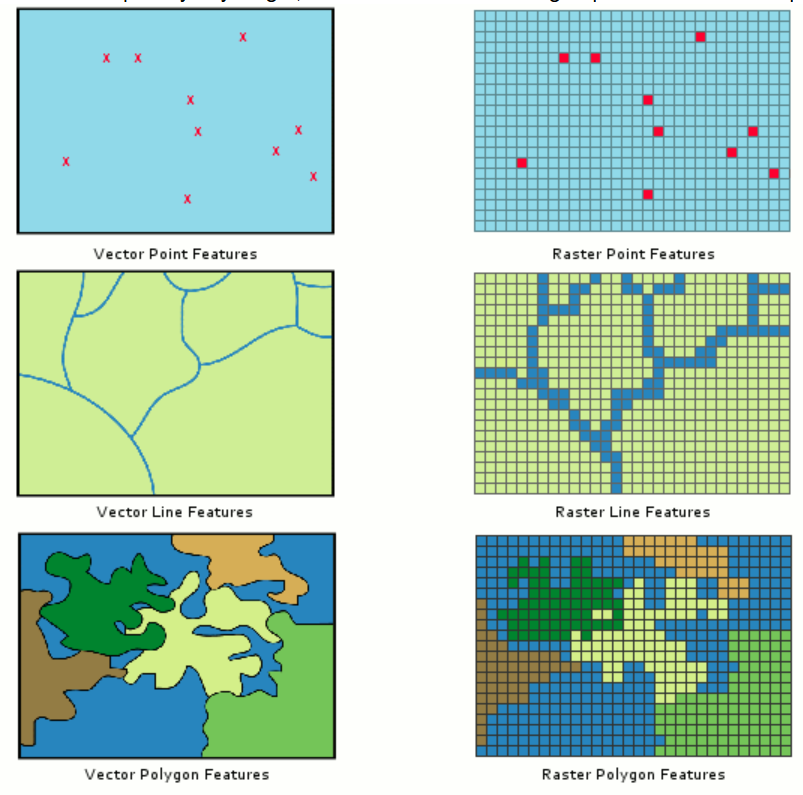


#### Data Structures
GeoPandas implements two main data structures, a GeoSeries and a GeoDataFrame. These are subclasses of pandas.Series and pandas.DataFrame, respectively.

#### GeoSeries
A GeoSeries is a special type of Pandas Series designed to store geometric shapes such as points, lines, or areas instead of just plain text or numbers.

Each row (entry) in a GeoSeries holds one shape — for example:
- A `Point`: Think of a pin on Google Maps. Example: The exact location of a hospital or shop.
- A `Polygon`: Represents an enclosed area on the map.e.g A country, park, or lake boundary.
- A `LineString`: Represents a path or route.e.g A road, river, or hiking trail.

Each row in the GeoSeries can hold either a single shape, or a collection of shapes.

You can have MultiPoints, MultiPolygons, or MultiLineStrings.

#### GeoDataFrame
A `GeoDataFrame` is a tabular data structure that contains a GeoSeries.

The most important property of a GeoDataFrame is that it always has one `GeoSeries` column that holds a special status - the `active geometry column`.

A GeoDataFrame may also contain other columns with geometrical (shapely) objects, but only one column can be the `active geometry` at a time. To change which column is the active geometry column, use the `GeoDataFrame.set_geometry()` method.

### Getting Geospatial Datasets
GeoPandas supports many geospatial file types and makes it easy to read and visualize them.

#### Common Dataset Formats
- Shapefile (.shp) – Standard GIS format for vector data.
- GeoJSON – JSON format for encoding geographic data.
- KML – Used by Google Earth.(Keyhole Markup Language)
- GPKG (GeoPackage) – Modern SQLite-based format.
- CSV – Can be converted to GeoDataFrame if it has latitude and longitude columns.

#### What is a Shapefile?
A shapefile is a popular file format used for storing geographic vector data—such as points (e.g., cities), lines (e.g., roads), and polygons (e.g., country borders).

A shapefile is not a single file but a group of files that work together. The most common ones are:

- `.shp`: the main file that contains geometry 
- `.shx`: an index file - makes the shape file faster
- `.dbf`: database (like a table of information), name, population, GDP
- `.prj`: projection (coordinate system info)

These files must be kept together in the same directory.

#### Installing Python GeoPandas

To use Python GeoPandas, you first have to install it, just like any other Python library.

`pip install geopandas` 

It’s important to note that GeoPandas relies on a stack of open-source geospatial libraries to deliver its full spatial potential, including `shapely`, `fiona`, `pyproj`, and `rtree`.

You have to make sure you install all these dependencies, otherwise, GeoPandas may not work as expected. 

In any case, if you have troubles during the installation of GeoPandas, you should check the [documentation](https://geopandas.org/en/stable/getting_started/install.html) for further information.

#### Geopandas Libraries

- Shapely is a Python library used for manipulating and analyzing geometric objects —  Built on top of GEOS
- `fiona` - reading and writing files, geojson
- `pyproj` - cartographic projections
- `descartes` - mapping
- `geopy` - geocoding
- `rtree` - Spatial analysis
- `pysal` - more advanced analysis, coloring maps

### Reading Spatial Data

In [1]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt

Natural Earth is a public domain map dataset that provides high-quality, free-to-use geospatial data for making maps and conducting geographic analysis.
Link to dataset: https://www.naturalearthdata.com/

In [2]:
# load the shapefile
world = gpd.read_file("world_countries/ne_10m_admin_0_countries.shp")

world.head()

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,0,2,Indonesia,IDN,0,2,Sovereign country,1,Indonesia,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((117.70361 4.16341, 117.70361 4..."
1,Admin-0 country,0,3,Malaysia,MYS,0,2,Sovereign country,1,Malaysia,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((117.70361 4.16341, 117.69711 4..."
2,Admin-0 country,0,2,Chile,CHL,0,2,Sovereign country,1,Chile,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-69.51009 -17.50659, -69.50611..."
3,Admin-0 country,0,3,Bolivia,BOL,0,2,Sovereign country,1,Bolivia,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((-69.51009 -17.50659, -69.51009 -17.5..."
4,Admin-0 country,0,2,Peru,PER,0,2,Sovereign country,1,Peru,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-69.51009 -17.50659, -69.63832..."


| Column      | Description                                                                 |
|-------------|-----------------------------------------------------------------------------|
| featurecla  | Feature class — describes the feature type, like "Admin-0 country" (country-level boundary). |
| scalerank   | Rank for map generalization; lower = more important (for display at small scales). |
| LABELRANK   | Rank used for labeling features in maps — lower = higher priority.          |
| SOVEREIGNT  | The sovereign nation name (e.g., "Indonesia").                              |
| SOV_A3      | 3-letter country code for the sovereign nation (e.g., "IDN").               |
| ADM0_DIF    | Indicates if ADMIN and SOVEREIGNT differ. 0 = same, 1 = different.          |
| LEVEL       | Administrative level — 2 usually means country-level (Admin-0).             |
| TYPE        | Type of entity — often "Sovereign country" or "Disputed".                   |
| TLC         | Could indicate territory label category (less commonly used).               |
| ADMIN       | Official administrative name of the country.                                |

<Axes: >

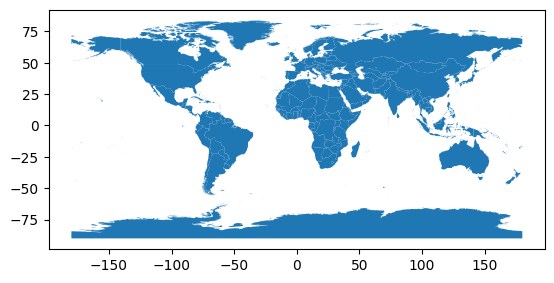

In [30]:
#plot the world map
world.plot()


In [5]:
# check the type
print(type(world))

<class 'geopandas.geodataframe.GeoDataFrame'>


In [6]:
# view columns
print(world.columns)

Index(['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3',
       'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'ADMIN',
       ...
       'FCLASS_TR', 'FCLASS_ID', 'FCLASS_PL', 'FCLASS_GR', 'FCLASS_IT',
       'FCLASS_NL', 'FCLASS_SE', 'FCLASS_BD', 'FCLASS_UA', 'geometry'],
      dtype='str', length=169)


In [7]:
world.geometry.head()

0    MULTIPOLYGON (((117.70361 4.16341, 117.70361 4...
1    MULTIPOLYGON (((117.70361 4.16341, 117.69711 4...
2    MULTIPOLYGON (((-69.51009 -17.50659, -69.50611...
3    POLYGON ((-69.51009 -17.50659, -69.51009 -17.5...
4    MULTIPOLYGON (((-69.51009 -17.50659, -69.63832...
Name: geometry, dtype: geometry

In [8]:
world['geometry'].head()

0    MULTIPOLYGON (((117.70361 4.16341, 117.70361 4...
1    MULTIPOLYGON (((117.70361 4.16341, 117.69711 4...
2    MULTIPOLYGON (((-69.51009 -17.50659, -69.50611...
3    POLYGON ((-69.51009 -17.50659, -69.51009 -17.5...
4    MULTIPOLYGON (((-69.51009 -17.50659, -69.63832...
Name: geometry, dtype: geometry

In [9]:
world.geom_type.value_counts()

MultiPolygon    151
Polygon         107
Name: count, dtype: int64

<Axes: >

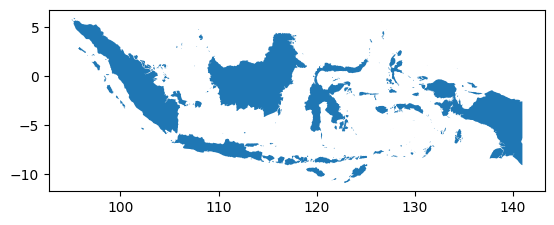

In [10]:
# Access the specific geometry of a country
country_shape = world.geometry.iloc[0]

# Create a plot of the specific country
plt.Figure(figsize=(10, 8))

# Plot the country shape
gpd.GeoSeries(country_shape).plot()

In [ ]:
world["ADMIN"].head(20)

0                        Indonesia
1                         Malaysia
2                            Chile
3                          Bolivia
4                             Peru
5                        Argentina
6     Dhekelia Sovereign Base Area
7                           Cyprus
8                            India
9                            China
10                          Israel
11                       Palestine
12                         Lebanon
13                        Ethiopia
14                     South Sudan
15                         Somalia
16                           Kenya
17                          Malawi
18     United Republic of Tanzania
19                           Syria
Name: ADMIN, dtype: str

<Axes: >

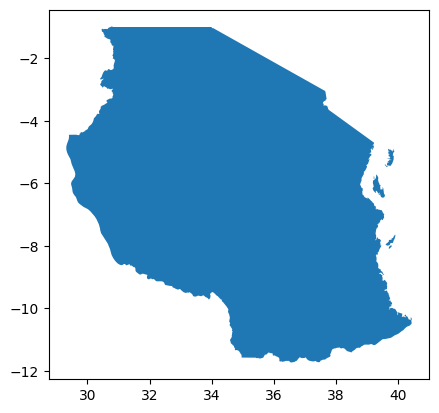

In [15]:
kenya = world[world['ADMIN'] == 'United Republic of Tanzania']
kenya.plot()
# kenya_shape = kenya.geometry
# gpd.GeoSeries(kenya_shape).plot()


In [14]:
world['ADMIN'].unique()

<StringArray>
[                   'Indonesia',                     'Malaysia',
                        'Chile',                      'Bolivia',
                         'Peru',                    'Argentina',
 'Dhekelia Sovereign Base Area',                       'Cyprus',
                        'India',                        'China',
 ...
     'Northern Mariana Islands',                      'Bahrain',
            'Coral Sea Islands',              'Spratly Islands',
            'Clipperton Island',                  'Macao S.A.R',
  'Ashmore and Cartier Islands', 'Bajo Nuevo Bank (Petrel Is.)',
              'Serranilla Bank',             'Scarborough Reef']
Length: 258, dtype: str

In [15]:
# Check the type
print(type(world)) 

<class 'geopandas.geodataframe.GeoDataFrame'>


In [16]:
# View columns
print(world.columns)

Index(['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3',
       'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'ADMIN',
       ...
       'FCLASS_TR', 'FCLASS_ID', 'FCLASS_PL', 'FCLASS_GR', 'FCLASS_IT',
       'FCLASS_NL', 'FCLASS_SE', 'FCLASS_BD', 'FCLASS_UA', 'geometry'],
      dtype='str', length=169)


#### Accessing the Geometry Column

In [17]:
# Access geometry
world.geometry.head()

0    MULTIPOLYGON (((117.70361 4.16341, 117.70361 4...
1    MULTIPOLYGON (((117.70361 4.16341, 117.69711 4...
2    MULTIPOLYGON (((-69.51009 -17.50659, -69.50611...
3    POLYGON ((-69.51009 -17.50659, -69.51009 -17.5...
4    MULTIPOLYGON (((-69.51009 -17.50659, -69.63832...
Name: geometry, dtype: geometry

In [18]:
world.geometry.extract_unique_points()
# world.geometry.unique()

0      MULTIPOINT ((117.70361 4.16341), (117.70361 4....
1      MULTIPOINT ((117.70361 4.16341), (117.69711 4....
2      MULTIPOINT ((-69.51009 -17.50659), (-69.50611 ...
3      MULTIPOINT ((-69.51009 -17.50659), (-69.51009 ...
4      MULTIPOINT ((-69.51009 -17.50659), (-69.63832 ...
                             ...                        
253    MULTIPOINT ((113.5586 22.16303), (113.56943 22...
254    MULTIPOINT ((123.59702 -12.42832), (123.59775 ...
255    MULTIPOINT ((-79.98929 15.79495), (-79.98782 1...
256    MULTIPOINT ((-78.63707 15.86209), (-78.64041 1...
257    MULTIPOINT ((117.75389 15.15437), (117.75569 1...
Length: 258, dtype: geometry

<Axes: >

<Figure size 1000x800 with 0 Axes>

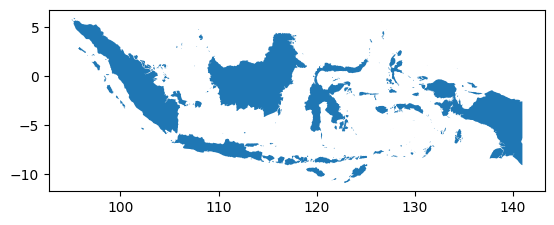

In [19]:
# Access a specific geometry
# Select the first country's shape
country_shape = world.geometry.iloc[0]
# Create a larger plot
plt.figure(figsize=(10, 8))  
# Plot the shape using a GeoSeries
gpd.GeoSeries([country_shape]).plot()

#### Activity 1: Country Geometry Viewer

- Pick a country from the GeoDataFrame.
- Access and plot its shape.

In [16]:
world['ADMIN'].unique()  # Unique country names

<StringArray>
[                   'Indonesia',                     'Malaysia',
                        'Chile',                      'Bolivia',
                         'Peru',                    'Argentina',
 'Dhekelia Sovereign Base Area',                       'Cyprus',
                        'India',                        'China',
 ...
     'Northern Mariana Islands',                      'Bahrain',
            'Coral Sea Islands',              'Spratly Islands',
            'Clipperton Island',                  'Macao S.A.R',
  'Ashmore and Cartier Islands', 'Bajo Nuevo Bank (Petrel Is.)',
              'Serranilla Bank',             'Scarborough Reef']
Length: 258, dtype: str

<Axes: >

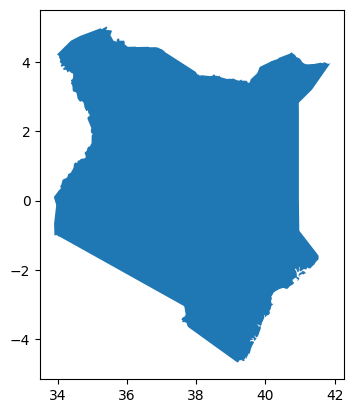

In [17]:
#Example: Select Kenya
kenya = world[world['ADMIN'] == 'Kenya']
kenya.plot()

 #### Activity 2: Geometry Type Checker
 Check the type of geometries in the dataset.

In [22]:
world.geom_type.value_counts()

MultiPolygon    151
Polygon         107
Name: count, dtype: int64

### Customizing map styles with geopandas

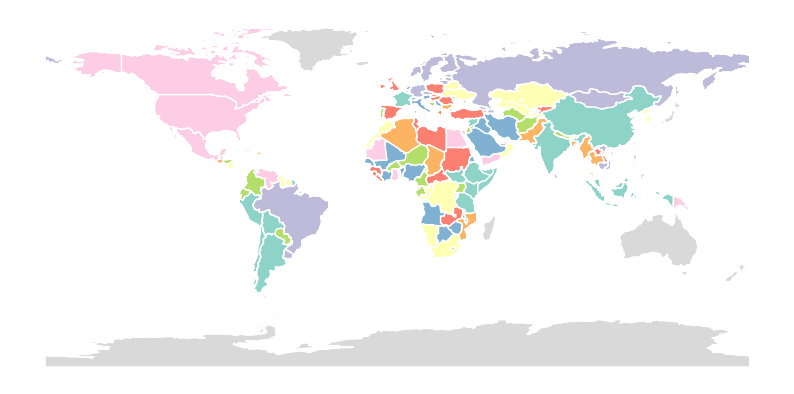

In [18]:
ax = world.plot(figsize=(10, 5), cmap='Set3', edgecolor='white')
ax.axis('off')
plt.show()


<Axes: >

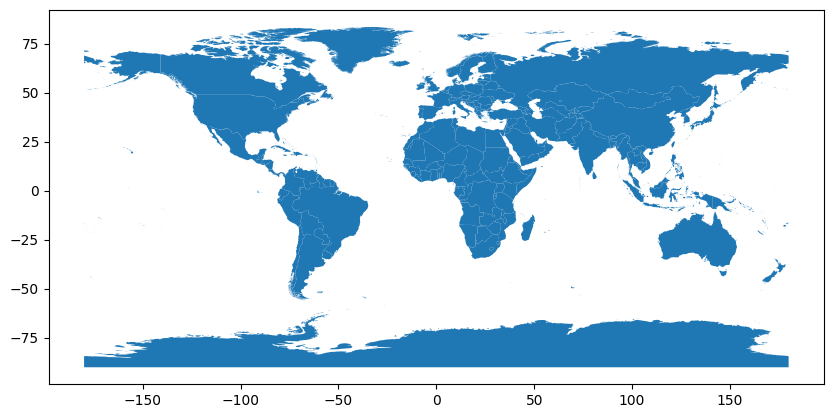

In [19]:
world.plot(figsize=(10,5))

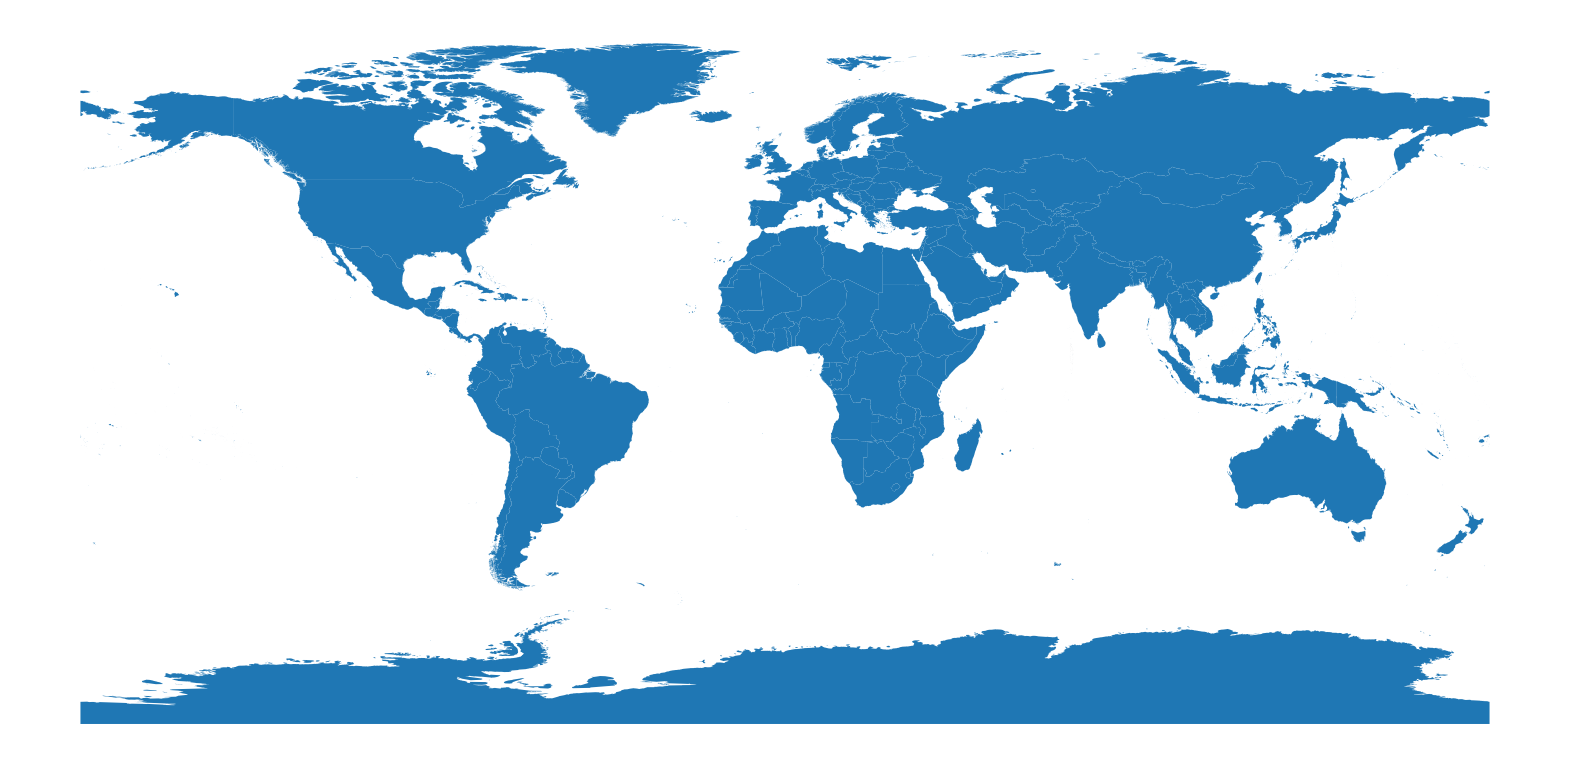

In [25]:
ax = world.plot(figsize=(20,20))
ax.axis('off')
plt.show()

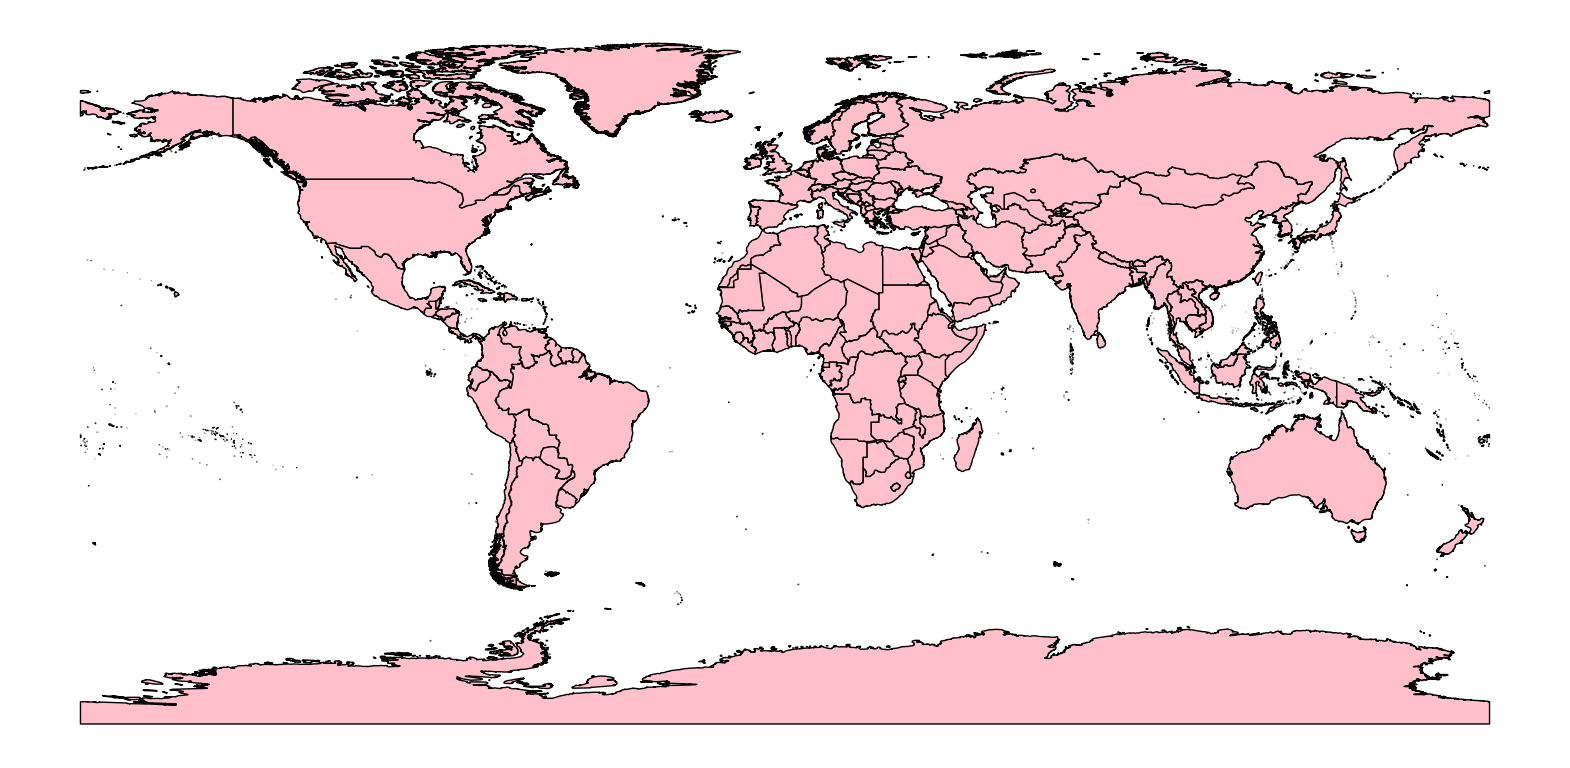

In [26]:
#coloring maps
# 1.fill - inside
# 2.edge - outline
ax = world.plot(figsize=(20,20), color = 'pink', edgecolor='black')
ax.axis('off')
plt.show()

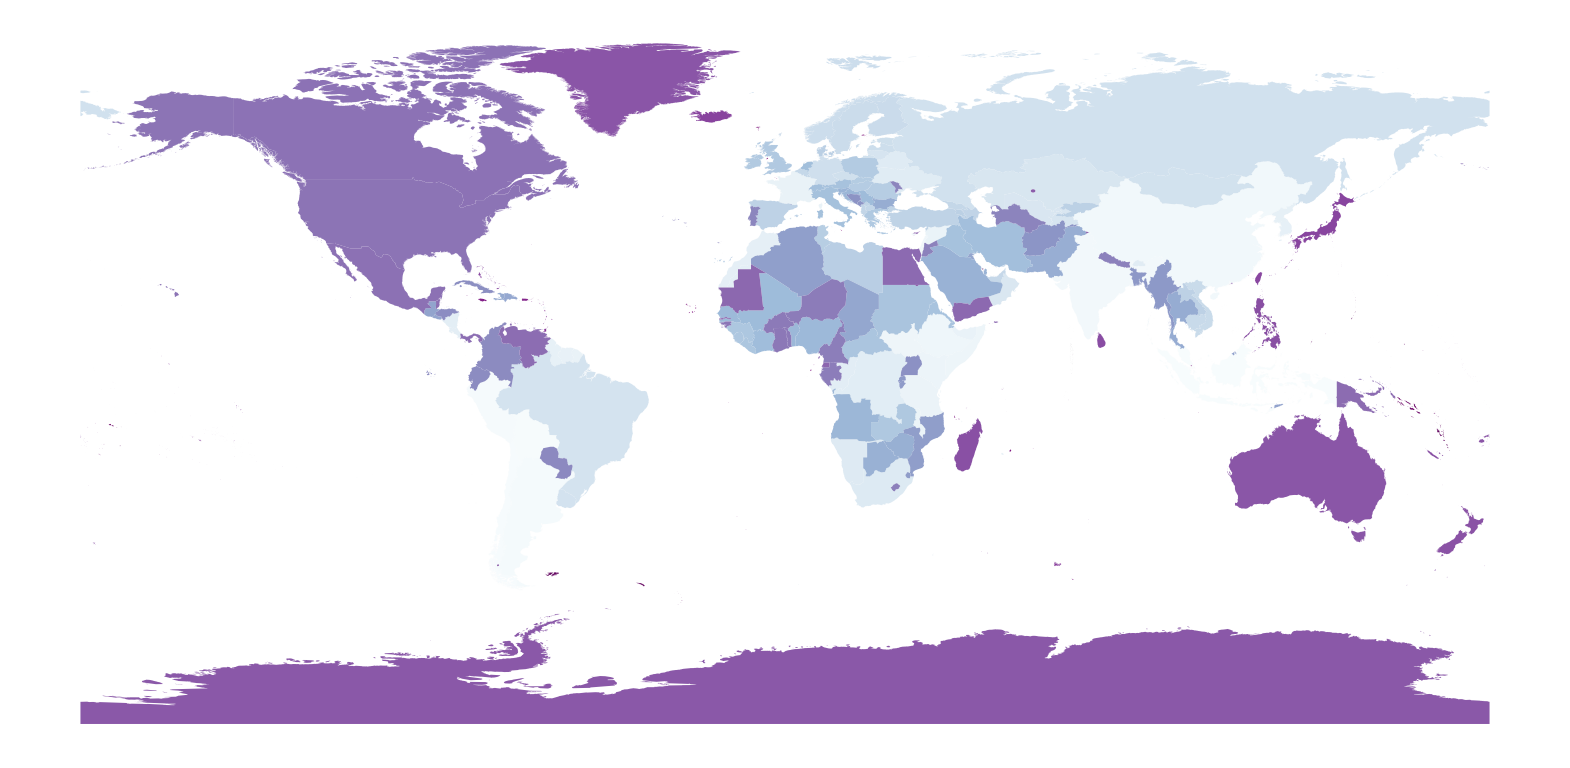

In [27]:
ax = world.plot(figsize=(20,20), cmap= 'BuPu')
ax.axis('off')
plt.show()

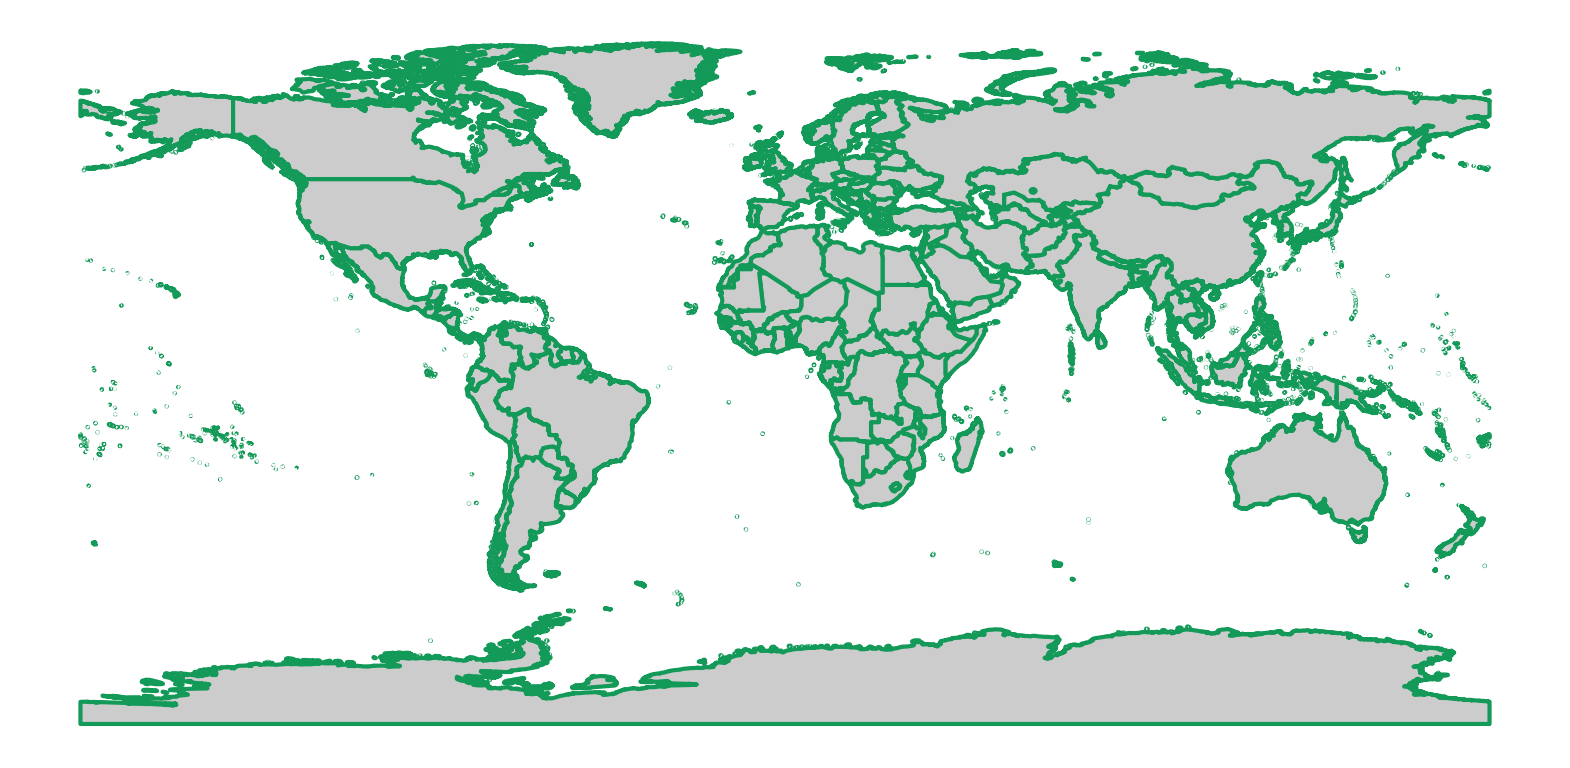

In [28]:
ax = world.plot(figsize=(20,20), color = '#CCCCCC', edgecolor="#139a59", linewidth=3)
ax.axis('off')
plt.show()

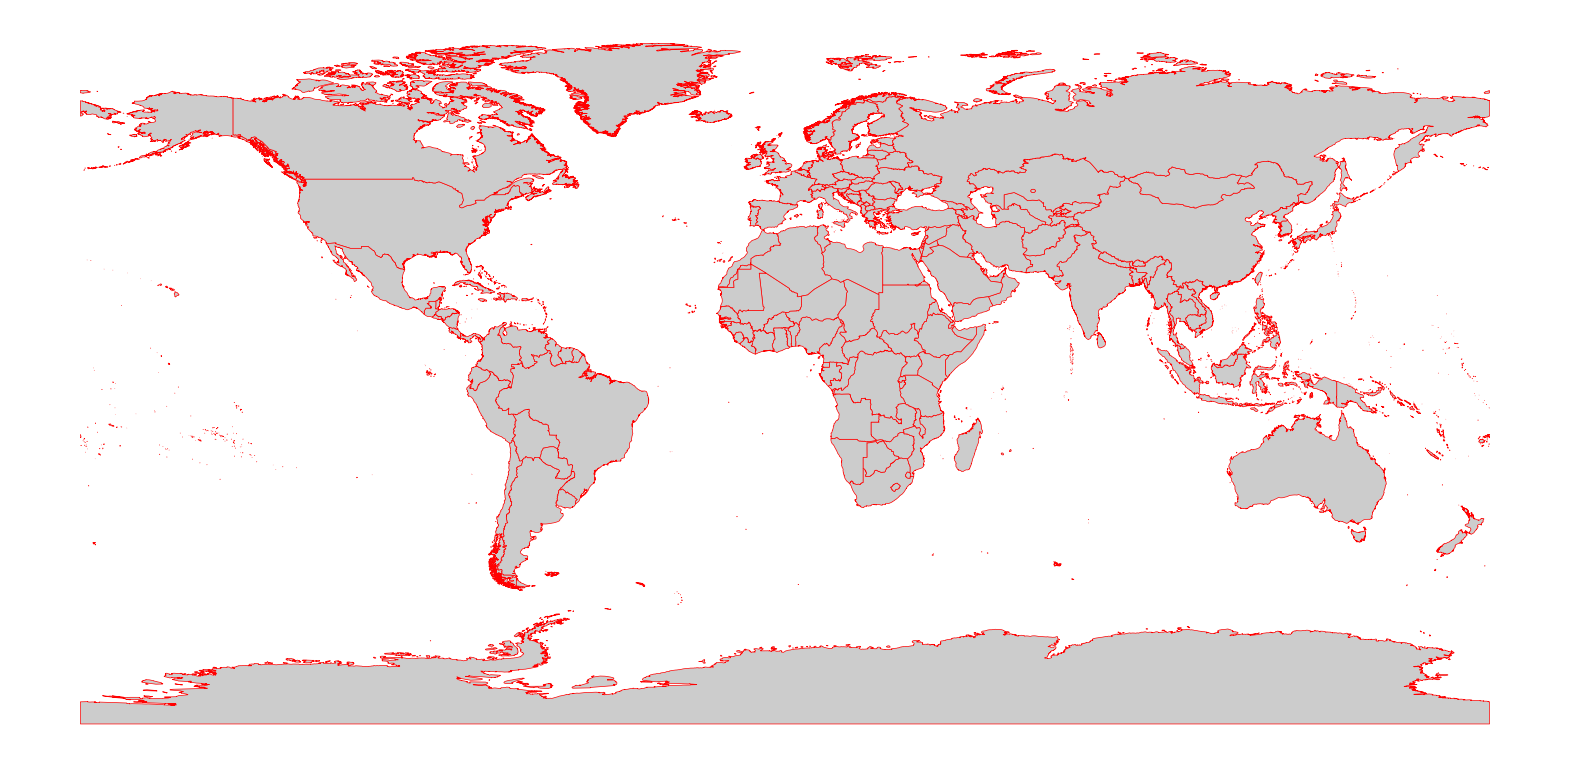

In [29]:
ax = world.plot(figsize=(20,20), color = '#CCCCCC', edgecolor='#FF0000', linewidth=0.5)
ax.axis('off')
plt.show()

## When Do We Use GeoPandas?

You use **GeoPandas** when you're working with **spatial data** any data that includes a geographic component. Typical scenarios include:

### 1. Mapping and Visualizing Geographic Data
- Plotting maps of countries, cities, or other regions.  
- **Example:** Visualizing population density across African countries.


### 2. Spatial Analysis
- Calculating areas, distances, centroids, or bounding boxes.  
- **Example:** Finding the area of forest cover in each country.

### 3. Working with Shapefiles or GeoJSON
- Reading `.shp`, `.geojson`, `.kml`, or other geographic file formats.  
- **Example:** Loading shapefiles of Nairobi's wards for mapping or analysis.

### 4. Filtering or Joining by Location
- Finding all schools within a 5 km radius of a hospital.  
- Joining datasets based on spatial location, like “which county each point belongs to.”

### 5. Coordinate Reference System (CRS) Handling
- Converting between different map projections.  
- **Example:** Reprojecting data from WGS84 (lat/lon) to UTM.


### Mapping and plotting tools

GeoPandas provides a high-level interface to the matplotlib library for making maps. Mapping shapes is as easy as using the plot() method on a GeoSeries or GeoDataFrame.

link to data: https://github.com/geopandas/geodatasets/blob/main/geodatasets/json/database.json

In [2]:
import geodatasets

In [29]:
airbnb = gpd.read_file(geodatasets.get_path('geoda.airbnb'))
airbnb.head()

,community,shape_area,shape_len,AREAID,response_r,accept_r,rev_rating,price_pp,room_type,num_spots,...,crowded,dependency,without_hs,unemployed,income_pc,harship_in,num_crimes,num_theft,population,geometry
0,DOUGLAS,46004621.1581,31027.0545098,35,98.771429,94.514286,87.777778,78.157895,1.789474,38,...,1.8,30.7,14.3,18.2,23791,47,5013,1241,18238,"POLYGON ((-87.60914 41.84469, -87.60915 41.844..."
1,OAKLAND,16913961.0408,19565.5061533,36,99.200000,90.105263,88.812500,53.775000,1.850000,20,...,1.3,40.4,18.4,28.7,19252,78,1306,311,5918,"POLYGON ((-87.59215 41.81693, -87.59231 41.816..."
2,FULLER PARK,19916704.8692,NaN,37,68.000000,NaN,91.750000,84.000000,1.833333,6,...,3.2,44.9,26.6,33.9,10432,97,1764,383,2876,"POLYGON ((-87.6288 41.80189, -87.62879 41.8017..."
3,GRAND BOULEVARD,48492503.1554,28196.8371573,38,94.037037,83.615385,92.750000,119.533333,1.533333,30,...,3.3,39.5,15.9,24.3,23472,57,6416,1428,21929,"POLYGON ((-87.60671 41.81681, -87.6067 41.8165..."
4,KENWOOD,29071741.9283,23325.1679062,39,92.542857,88.142857,90.656250,77.991453,1.615385,39,...,2.4,35.4,11.3,15.7,35911,26,2713,654,17841,"POLYGON ((-87.59215 41.81693, -87.59215 41.816..."


<Axes: >

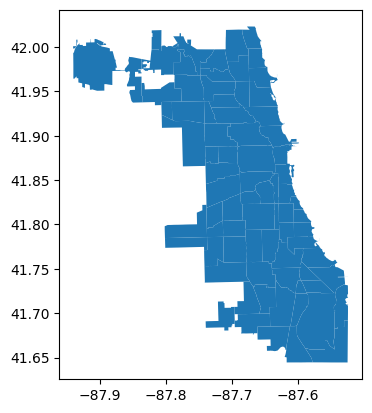

In [30]:
airbnb.plot()

In [31]:
#chicago.head()
airbnb.head()

,community,shape_area,shape_len,AREAID,response_r,accept_r,rev_rating,price_pp,room_type,num_spots,...,crowded,dependency,without_hs,unemployed,income_pc,harship_in,num_crimes,num_theft,population,geometry
0,DOUGLAS,46004621.1581,31027.0545098,35,98.771429,94.514286,87.777778,78.157895,1.789474,38,...,1.8,30.7,14.3,18.2,23791,47,5013,1241,18238,"POLYGON ((-87.60914 41.84469, -87.60915 41.844..."
1,OAKLAND,16913961.0408,19565.5061533,36,99.200000,90.105263,88.812500,53.775000,1.850000,20,...,1.3,40.4,18.4,28.7,19252,78,1306,311,5918,"POLYGON ((-87.59215 41.81693, -87.59231 41.816..."
2,FULLER PARK,19916704.8692,NaN,37,68.000000,NaN,91.750000,84.000000,1.833333,6,...,3.2,44.9,26.6,33.9,10432,97,1764,383,2876,"POLYGON ((-87.6288 41.80189, -87.62879 41.8017..."
3,GRAND BOULEVARD,48492503.1554,28196.8371573,38,94.037037,83.615385,92.750000,119.533333,1.533333,30,...,3.3,39.5,15.9,24.3,23472,57,6416,1428,21929,"POLYGON ((-87.60671 41.81681, -87.6067 41.8165..."
4,KENWOOD,29071741.9283,23325.1679062,39,92.542857,88.142857,90.656250,77.991453,1.615385,39,...,2.4,35.4,11.3,15.7,35911,26,2713,654,17841,"POLYGON ((-87.59215 41.81693, -87.59215 41.816..."


<Axes: >

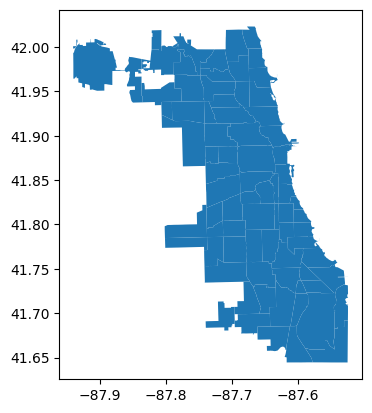

In [33]:
airbnb.plot()

#### Choropleth maps
GeoPandas makes it easy to create Choropleth maps (maps where the color of each shape is based on the value of an associated variable).

Simply use the plot command with the column argument set to the column whose values you want used to assign colors.

<Axes: >

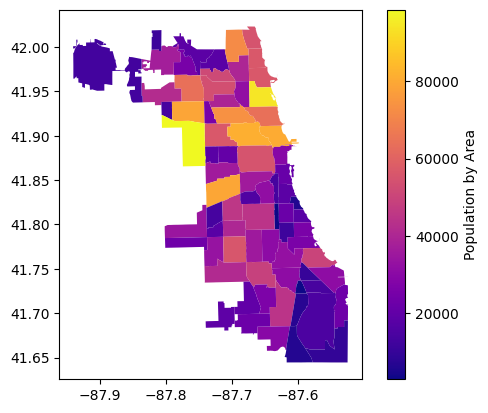

In [32]:
# Plot by population
airbnb.plot(
    column = 'population', 
    legend=True, 
    legend_kwds={'label': "Population by Area"},
    cmap='plasma')

<Axes: >

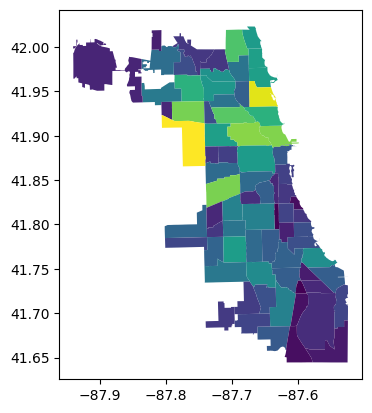

In [33]:
#Plot by population
airbnb.plot(column="population")

### Creating a legend
When plotting a map, we can enable a legend using the legend argument:

<Axes: >

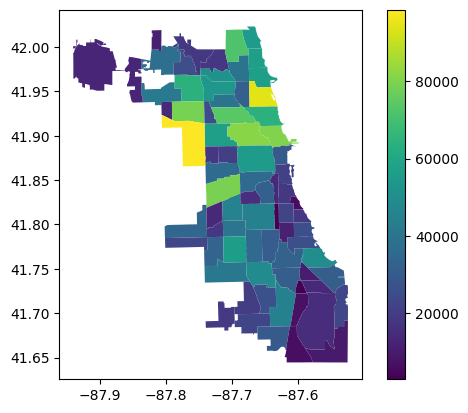

In [35]:
#Plot population estimates with an accurate legend
airbnb.plot(column='population', legend=True)

<Axes: >

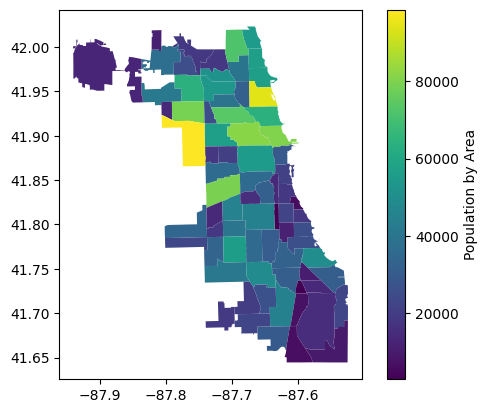

In [59]:
# adds its label using using legend_kwds
airbnb.plot(
    column="population",
    legend=True,
    legend_kwds={"label": "Population by Area"},
)

### Choosing colors
- You can also modify the colors used by plot() with the cmap option. 
- For a full list of colormaps, https://matplotlib.org/stable/users/explain/colors/colormaps.html.

#### Sequential (Good for ordered/numeric data like population, income)
Use when values have a natural order (low to high).
- 'viridis' (default and perceptually uniform)
- 'plasma'
- 'inferno'
- 'magma'
- 'cividis'
- 'Blues', 'Greens', 'Reds', 'Purples'
- 'YlOrRd', 'OrRd', 'BuPu', 'YlGnBu'

<Axes: >

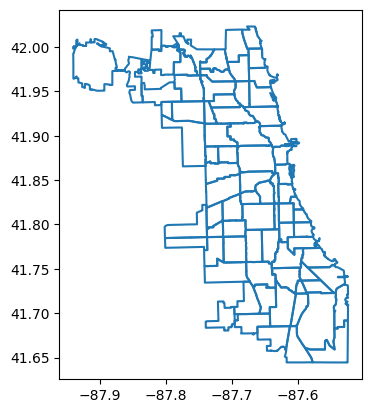

In [60]:
airbnb.boundary.plot()

<Axes: >

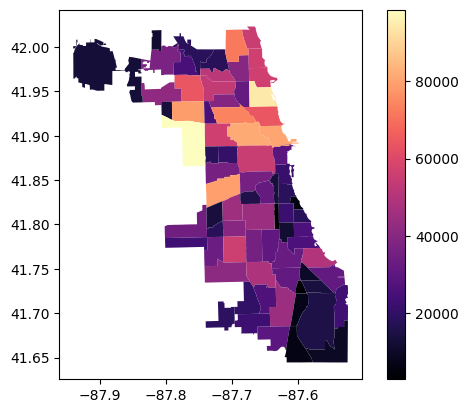

In [49]:
airbnb.plot(column='population', cmap='magma', legend=True)

In [50]:
plt.colormaps()

['magma',
 'inferno',
 'plasma',
 'viridis',
 'cividis',
 'twilight',
 'twilight_shifted',
 'turbo',
 'berlin',
 'managua',
 'vanimo',
 'Blues',
 'BrBG',
 'BuGn',
 'BuPu',
 'CMRmap',
 'GnBu',
 'Greens',
 'Greys',
 'OrRd',
 'Oranges',
 'PRGn',
 'PiYG',
 'PuBu',
 'PuBuGn',
 'PuOr',
 'PuRd',
 'Purples',
 'RdBu',
 'RdGy',
 'RdPu',
 'RdYlBu',
 'RdYlGn',
 'Reds',
 'Spectral',
 'Wistia',
 'YlGn',
 'YlGnBu',
 'YlOrBr',
 'YlOrRd',
 'afmhot',
 'autumn',
 'binary',
 'bone',
 'brg',
 'bwr',
 'cool',
 'coolwarm',
 'copper',
 'cubehelix',
 'flag',
 'gist_earth',
 'gist_gray',
 'gist_heat',
 'gist_ncar',
 'gist_rainbow',
 'gist_stern',
 'gist_yarg',
 'gnuplot',
 'gnuplot2',
 'gray',
 'hot',
 'hsv',
 'jet',
 'nipy_spectral',
 'ocean',
 'pink',
 'prism',
 'rainbow',
 'seismic',
 'spring',
 'summer',
 'terrain',
 'winter',
 'Accent',
 'Dark2',
 'Paired',
 'Pastel1',
 'Pastel2',
 'Set1',
 'Set2',
 'Set3',
 'tab10',
 'tab20',
 'tab20b',
 'tab20c',
 'grey',
 'gist_grey',
 'gist_yerg',
 'Grays',
 'magma_r',

<Axes: >

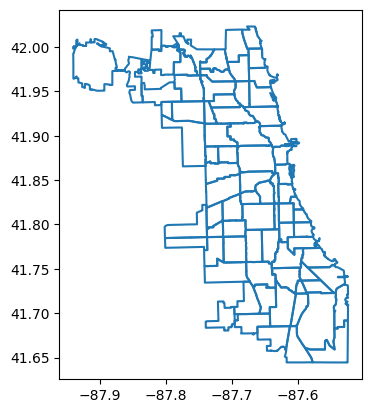

In [51]:
# To make the color transparent for when you just want to show the boundary,
#chicago.plot(facecolor="none", edgecolor="black")
#airbnb.plot(facecolor="none")
airbnb.boundary.plot()

### choropleth classification schemes

Data classification is the process of grouping continuous or numeric data into discrete categories (or classes) so that they can be visually represented with different colors or shades in a choropleth map.

In libraries like GeoPandas and matplotlib, when you create a choropleth map, you can use the scheme option (powered by the mapclassify package) to control how the values are divided into color bins.

#### Examples of Classification Schemes (`mapclassify`)

Some common classification schemes available via `mapclassify`:

| Scheme           | Description                                                                 |
|------------------|-----------------------------------------------------------------------------|
| `equal_interval` | Divides data range into equal-sized intervals.                             |
| `quantiles`      | Each class contains the same number of observations.                       |               |
| `box_plot`       | Based on quartiles and outliers, like in a box plot.                       |
| `std_mean`       | Classification based on standard deviations from the mean.                |
| `fisher_jenks`   | Minimizes variance within classes, maximizes variance between classes.     |


<Axes: >

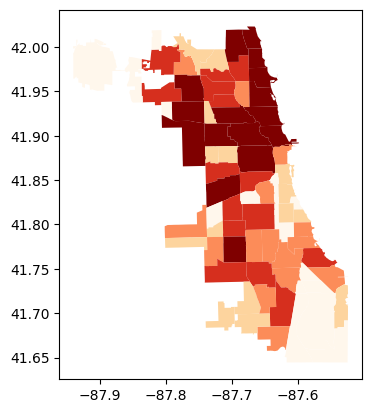

In [53]:
airbnb.plot(column='population', cmap='OrRd', scheme='quantiles')

### Interactive mapping

Geopandas can create interactive maps based on the folium library.

pip install folium branca

- Folium: Folium is a Python library that enables the creation of interactive maps, leveraging the capabilities of the Leaflet JavaScript library.
- Branca: A helper library used by Folium to handle tooltips, legends, color maps, and popups.





In [3]:
import folium

In [4]:
atlanta = gpd.read_file(geodatasets.get_path('geoda.atlanta'))
atlanta.head()

,NAME,STATE_NAME,STATE_FIPS,CNTY_FIPS,FIPS,STFIPS,COFIPS,FIPSNO,HR7983,HR8587,...,PO7983,PO8587,PO8995,PE77,PE82,PE87,RDAC80,RDAC85,RDAC90,geometry
0,Cherokee,North Carolina,37,039,37039,37,39,37039,6.298816,6.742065,...,95256,59329,144758,2.933480,1.605377,1.922455,0.897757,0.444341,0.134578,"POLYGON ((-84.29104 35.21054, -84.22594 35.261..."
1,Polk,Tennessee,47,139,47139,47,139,47139,13.271204,9.629968,...,67816,41537,97210,4.422696,3.994711,3.833682,-0.012454,-0.140179,-0.192610,"POLYGON ((-84.29104 35.21054, -84.32385 34.989..."
2,Oconee,South Carolina,45,073,45073,45,73,45073,14.174115,6.246720,...,246929,160084,413465,3.716055,3.635228,3.789255,-0.168537,-0.311719,-0.368479,"POLYGON ((-83.05512 34.48996, -83.07915 34.518..."
3,Rabun,Georgia,13,241,13241,13,241,13241,13.306214,6.038830,...,52607,33119,83962,2.637461,2.625957,4.394626,0.449209,0.058768,-0.229536,"POLYGON ((-83.3508 34.70955, -83.39137 34.7288..."
4,Whitfield,Georgia,13,313,13313,13,313,13313,10.274169,6.715627,...,330927,208469,524696,4.099088,2.877935,2.452316,-0.318807,-0.476584,-0.566740,"POLYGON ((-85.047 34.62268, -85.04798 34.71451..."


In [5]:
atlanta.explore()

In [65]:
atlanta.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 24 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   NAME        90 non-null     str     
 1   STATE_NAME  90 non-null     str     
 2   STATE_FIPS  90 non-null     str     
 3   CNTY_FIPS   90 non-null     str     
 4   FIPS        90 non-null     str     
 5   STFIPS      90 non-null     int32   
 6   COFIPS      90 non-null     int32   
 7   FIPSNO      90 non-null     int32   
 8   HR7983      90 non-null     float64 
 9   HR8587      90 non-null     float64 
 10  HR8995      90 non-null     float64 
 11  HC7983      90 non-null     int32   
 12  HC8587      90 non-null     int32   
 13  HC8995      90 non-null     int32   
 14  PO7983      90 non-null     int32   
 15  PO8587      90 non-null     int32   
 16  PO8995      90 non-null     int32   
 17  PE77        90 non-null     float64 
 18  PE82        90 non-null     float64 
 19  PE

In [6]:
atlanta.explore(
    column="HR7983",               
    cmap="Reds",                  
    legend=True,                  
    tooltip=["NAME", "HR7983"],   
    style_kwds={"fillOpacity": 0.8, "weight": 0.8},
    highlight=False
 )

In [7]:
# Load the Atlanta homicide dataset using its registered name
atlanta = gpd.read_file(geodatasets.get_path("geoda.atlanta"))

In [8]:
# View the first few rows
atlanta.head()

,NAME,STATE_NAME,STATE_FIPS,CNTY_FIPS,FIPS,STFIPS,COFIPS,FIPSNO,HR7983,HR8587,...,PO7983,PO8587,PO8995,PE77,PE82,PE87,RDAC80,RDAC85,RDAC90,geometry
0,Cherokee,North Carolina,37,039,37039,37,39,37039,6.298816,6.742065,...,95256,59329,144758,2.933480,1.605377,1.922455,0.897757,0.444341,0.134578,"POLYGON ((-84.29104 35.21054, -84.22594 35.261..."
1,Polk,Tennessee,47,139,47139,47,139,47139,13.271204,9.629968,...,67816,41537,97210,4.422696,3.994711,3.833682,-0.012454,-0.140179,-0.192610,"POLYGON ((-84.29104 35.21054, -84.32385 34.989..."
2,Oconee,South Carolina,45,073,45073,45,73,45073,14.174115,6.246720,...,246929,160084,413465,3.716055,3.635228,3.789255,-0.168537,-0.311719,-0.368479,"POLYGON ((-83.05512 34.48996, -83.07915 34.518..."
3,Rabun,Georgia,13,241,13241,13,241,13241,13.306214,6.038830,...,52607,33119,83962,2.637461,2.625957,4.394626,0.449209,0.058768,-0.229536,"POLYGON ((-83.3508 34.70955, -83.39137 34.7288..."
4,Whitfield,Georgia,13,313,13313,13,313,13313,10.274169,6.715627,...,330927,208469,524696,4.099088,2.877935,2.452316,-0.318807,-0.476584,-0.566740,"POLYGON ((-85.047 34.62268, -85.04798 34.71451..."


In [8]:
atlanta.explore()

In [103]:
# customised choropleth map
atlanta.explore(
    column="HR7983",               
    cmap="Reds",                   # Color map for intensity
    legend=True,                  
    tooltip=["NAME", "HR7983"],    # Tooltip shows county name + homicide rate
    style_kwds={"fillOpacity": 0.9, "weight": 0.8}, #weight : thickness of the polygon borders
    highlight=False
 ) # adds a visual effect to the map so that when your mouse hovers over a region, that region stands out.

#### Creating a Folium Map

In [110]:
map_centre = [atlanta.geometry.centroid.y.mean(), atlanta.geometry.centroid.x.mean()]
m = folium.Map(location= map_centre, zoom_start=6)
m

C:\Users\user\AppData\Local\Temp\ipykernel_13364\2564094350.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  map_centre = [atlanta.geometry.centroid.y.mean(), atlanta.geometry.centroid.x.mean()]


In [112]:
# Get the top 5 counties by homicide rate
top5 = atlanta.nlargest(5, 'HR8995')

# Marker for the top 5 counties
for _, row in top5.iterrows():
    location = [row.geometry.centroid.y, row.geometry.centroid.x]
    rate = row['HR8995']
    name = row['NAME']

    folium.CircleMarker(
        location = location,
        radius = 5 + rate / 5,
        color = 'crimson', 
        fill= True,
        fill_color = 'crimson', 
        fill_opacity = 0.8
    ).add_to(m)

    m

In [98]:
# Create a base map centered around the average location of the counties
# centroid (center point) of each polygon (like a county or district) in atlanta.
map_center = [atlanta.geometry.centroid.y.mean(), atlanta.geometry.centroid.x.mean()]
m = folium.Map(location=map_center, zoom_start=6)
m

C:\Users\user\AppData\Local\Temp\ipykernel_13364\3476393867.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  map_center = [atlanta.geometry.centroid.y.mean(), atlanta.geometry.centroid.x.mean()]


### Adding markers

In [99]:
# Add a simple marker (e.g., downtown Atlanta)
folium.Marker(
    location=[33.7490, -84.3880],  # Latitude and longitude of downtown Atlanta
    popup="Downtown Atlanta",      # Message when you click the marker
    tooltip="Click me!"            # Message when you hover
).add_to(m)

# Show the map
m

In [100]:
# Add a circle marker (can show quantity/importance with radius or color)
folium.CircleMarker(
    location=[33.7490, -84.3880],
    radius=10,
    color='blue',
    fill=True,
    fill_color='cyan',
    fill_opacity=0.7,
    popup='Circle Marker: Downtown Atlanta'
).add_to(m)

m

In [114]:
# Get top 5 counties by homicide rate (HR8995)
top5 = atlanta.nlargest(5, 'HR8995')

# Add circle markers for top 5 high-risk counties
for _, row in top5.iterrows():
    location = [row.geometry.centroid.y, row.geometry.centroid.x]
    rate = row['HR8995']
    name = row['NAME']
    
    folium.CircleMarker(
        location=location,
        radius=5 + rate / 5,  # size reflects homicide rate
        color='crimson',
        fill=True,
        fill_color='crimson',
        fill_opacity=0.8,
        popup=f"{name} County<br>Homicide Rate: {rate:.1f}"
    ).add_to(m)

# Display the map
m

#### Adding Tooltips 

In [14]:
from branca.element import Template, MacroElement

In [15]:

# Top 5 high-risk counties
top5 = atlanta.nlargest(5, 'HR8995')

# Add circle markers with tooltips and popups
# _ looping through rows, but I’m not using the index
for _, row in top5.iterrows():
    location = [row.geometry.centroid.y, row.geometry.centroid.x]
    rate = row['HR8995']
    name = row['NAME']
    
    folium.CircleMarker(
        location=location,
        radius=5 + rate / 5,
        color='crimson',
        fill=True,
        fill_color='crimson',
        fill_opacity=0.8,
        popup=folium.Popup(f"<b>{name} County</b><br>Homicide Rate: {rate:.1f}", max_width=250),
        tooltip=f"{name} County"
    ).add_to(m)

m

#### Add Choropleth Layer (e.g., map by population or a variable like PO8995)

In [16]:
# Choose a numeric column to color counties by
value_column = 'PO8995' 

# Add interactive choropleth layer
folium.Choropleth(
    geo_data=atlanta,
    name='Choropleth',
    data=atlanta,
    columns=['NAME', value_column],  
    key_on='feature.properties.NAME',
    fill_color='YlGnBu',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Population in 1995'
).add_to(m)
m

In [43]:
from folium.features import GeoJsonTooltip

In [65]:
folium.GeoJson(
    atlanta,
    name="Counties",
    tooltip=GeoJsonTooltip(fields=["NAME", value_column],
                           aliases=["County:", "Population (1995):"],
                           localize=True)
).add_to(m)
m